# Eksperymenty porównawcze VGG16 vs AlexNet vs GoogLeNet

Do przeprowadzenia eksperymentów należy wcześniej wytrenować modele z wykorzystaniem skryptu `prepare_models`, który zapisze wytrenowane modele w folderze `models` pod nazwami:

- `vgg16_cifar10.pth`
- `alexnet_cifar10.pth`
- `googlenet_cifar10.pth`

Nalezy również mieć przygotowane obrazy z modyfikacjami, które można uzyskać za pomocą skryptu `prepare_images`. Skrypt ten powinien umieścić obrazy w następujących folderach:

- `modified_images/` - warianty jednego obrazu klasy `ship`, razem z oryginałem
- `external_images/` - obrazy spoza CIFAR-10

Predykcja, ładowanie modeli oraz ewaluacja są wykonywane przez funkcje z `adom_library`. Notebook służy głównie do uruchamiania eksperymentów, prezentacji wyników i eksportu tabel.

## Import i wczytywanie modeli

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

import adom_library as adom
import adom_images as images

adom.show_device()

MODEL_SPECS = {
    "VGG16": {"model_name": "vgg16_cifar10", "model_type": "VGG16"},
    "AlexNet": {"model_name": "alexnet_cifar10", "model_type": "AlexNet"},
    "GoogLeNet": {"model_name": "googlenet_cifar10", "model_type": "GoogleNet"},
}

MODIFIED_IMAGES_DIR = Path("modified_images")
EXTERNAL_IMAGES_DIR = Path("external_images")
RESULTS_DIR = Path("experiments_results")
RESULTS_DIR.mkdir(exist_ok=True)

BATCH_SIZE = 64


def export_to_csv(df: pd.DataFrame, filename: str):
    output_path = RESULTS_DIR / filename
    df.to_csv(output_path, index=False)

cuda


In [2]:
loaded_models, classes = adom.load_models(MODEL_SPECS)

print("Wczytane modele:")
for model_name, info in loaded_models.items():
    print(f"- {model_name}: {info['model_name']} ({info['model_type']})")

print("\nKlasy CIFAR-10:")
print(classes)

d:\Projekty\Studia\ADOM\ADOM_2026L_Deep_CNN-VGG\adom_library.py:282: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_info = torch.load(MODELS_ROOT + "/" + model_name + "

Wczytane modele:
- VGG16: vgg16_cifar10 (VGG16)
- AlexNet: alexnet_cifar10 (AlexNet)
- GoogLeNet: googlenet_cifar10 (GoogleNet)

Klasy CIFAR-10:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


d:\Projekty\Studia\ADOM\ADOM_2026L_Deep_CNN-VGG\.venv\Lib\site-packages\torchvision\models\googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


## Porównanie liczby parametrów

In [3]:
params_rows = []

for model_name, info in loaded_models.items():
    params_rows.append({
        "model": model_name,
        "parameters": adom.count_model_params(info["model"]),
    })

params_df = pd.DataFrame(params_rows).sort_values("parameters", ascending=False)
display(params_df)

export_to_csv(params_df, "model_parameters.csv")

,model,parameters
0,VGG16,134301514
1,AlexNet,57044810
2,GoogLeNet,5610154


## Ewaluacja na pełnym zbiorze testowym CIFAR-10

### Ogólne wyniki

In [4]:
test_dataset = adom.get_CIFAR10_dataset(train_dataset=False, perform_transform=True)

cifar10_results = adom.evaluate_models_on_dataset(
    loaded_models=loaded_models,
    dataset=test_dataset,
    classes=classes,
    batch_size=BATCH_SIZE,
)

summary_rows = []
for model_name, result in cifar10_results.items():
    summary_rows.append({
        "model": model_name,
        "accuracy_percent": result["accuracy_percent"],
        "avg_loss": result["avg_loss"],
        "correct": result["correct"],
        "total": result["total"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("accuracy_percent", ascending=False)
display(summary_df)

export_to_csv(summary_df, "cifar10_evaluation_summary.csv")

Files already downloaded and verified


d:\Projekty\Studia\ADOM\ADOM_2026L_Deep_CNN-VGG\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


,model,accuracy_percent,avg_loss,correct,total
2,GoogLeNet,82.19,0.598081,8219,10000
1,AlexNet,80.11,0.846503,8011,10000
0,VGG16,77.11,1.083695,7711,10000


### Interpretacja ogólnych wyników

Ten wynik należy traktować jako główne porównanie jakości klasyfikacji, ponieważ obejmuje cały zbiór testowy CIFAR-10, a nie pojedyncze obrazy.

In [5]:
best = summary_df.iloc[0]
worst = summary_df.iloc[-1]

print(f"Najlepszy wynik uzyskał model: {best['model']} ({best['accuracy_percent']:.2f}%)")
print(f"Najsłabszy wynik uzyskał model: {worst['model']} ({worst['accuracy_percent']:.2f}%)")

Najlepszy wynik uzyskał model: GoogLeNet (82.19%)
Najsłabszy wynik uzyskał model: VGG16 (77.11%)


### Wyniki per klasa

Ten eksperyment pokazuje, które klasy są łatwiejsze lub trudniejsze dla poszczególnych architektur.

In [6]:
per_class_rows = []

for model_name, result in cifar10_results.items():
    for class_name, acc in result["per_class_accuracy"].items():
        per_class_rows.append({
            "model": model_name,
            "class": class_name,
            "accuracy_percent": acc * 100,
            "correct": result["per_class_correct"][class_name],
            "total": result["per_class_total"][class_name],
        })

per_class_df = pd.DataFrame(per_class_rows)
display(per_class_df.sort_values(["model", "accuracy_percent"], ascending=[True, False]))

export_to_csv(per_class_df, "cifar10_per_class_accuracy.csv")

print("Podsumowanie najlepszych i najgorszych klas dla każdego modelu:")
for model_name in per_class_df["model"].unique():
    model_df = per_class_df[per_class_df["model"] == model_name].sort_values("accuracy_percent", ascending=False)
    best_class = model_df.iloc[0]
    worst_class = model_df.iloc[-1]
    print(f"{model_name}:")
    print(f"  Najlepsza klasa: {best_class['class']} - {best_class['accuracy_percent']:.2f}%")
    print(f"  Najgorsza klasa: {worst_class['class']} - {worst_class['accuracy_percent']:.2f}%")

,model,class,accuracy_percent,correct,total
19,AlexNet,truck,88.7,887,1000
11,AlexNet,automobile,88.6,886,1000
10,AlexNet,airplane,86.4,864,1000
16,AlexNet,frog,85.1,851,1000
18,AlexNet,ship,85.1,851,1000
17,AlexNet,horse,80.9,809,1000
13,AlexNet,cat,80.6,806,1000
12,AlexNet,bird,69.2,692,1000
14,AlexNet,deer,68.8,688,1000
15,AlexNet,dog,67.7,677,1000


Podsumowanie najlepszych i najgorszych klas dla każdego modelu:
VGG16:
  Najlepsza klasa: ship - 87.70%
  Najgorsza klasa: cat - 51.70%
AlexNet:
  Najlepsza klasa: truck - 88.70%
  Najgorsza klasa: dog - 67.70%
GoogLeNet:
  Najlepsza klasa: frog - 95.30%
  Najgorsza klasa: dog - 66.70%


### Wykres wyników per klasa

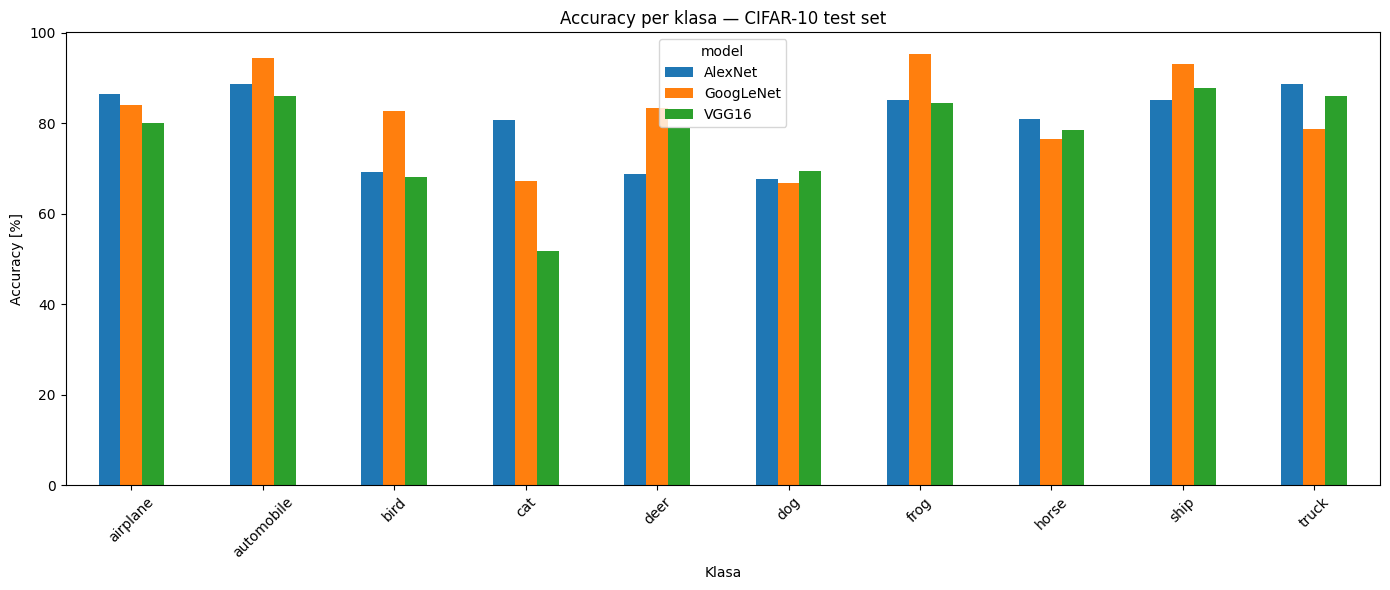

In [7]:
per_class_pivot = per_class_df.pivot(index="class", columns="model", values="accuracy_percent")
ax = per_class_pivot.plot(kind="bar", figsize=(14, 6))
ax.set_title("Accuracy per klasa — CIFAR-10 test set")
ax.set_xlabel("Klasa")
ax.set_ylabel("Accuracy [%]")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Badanie wpływu modyfikacji obrazów na wyniki klasyfikacji

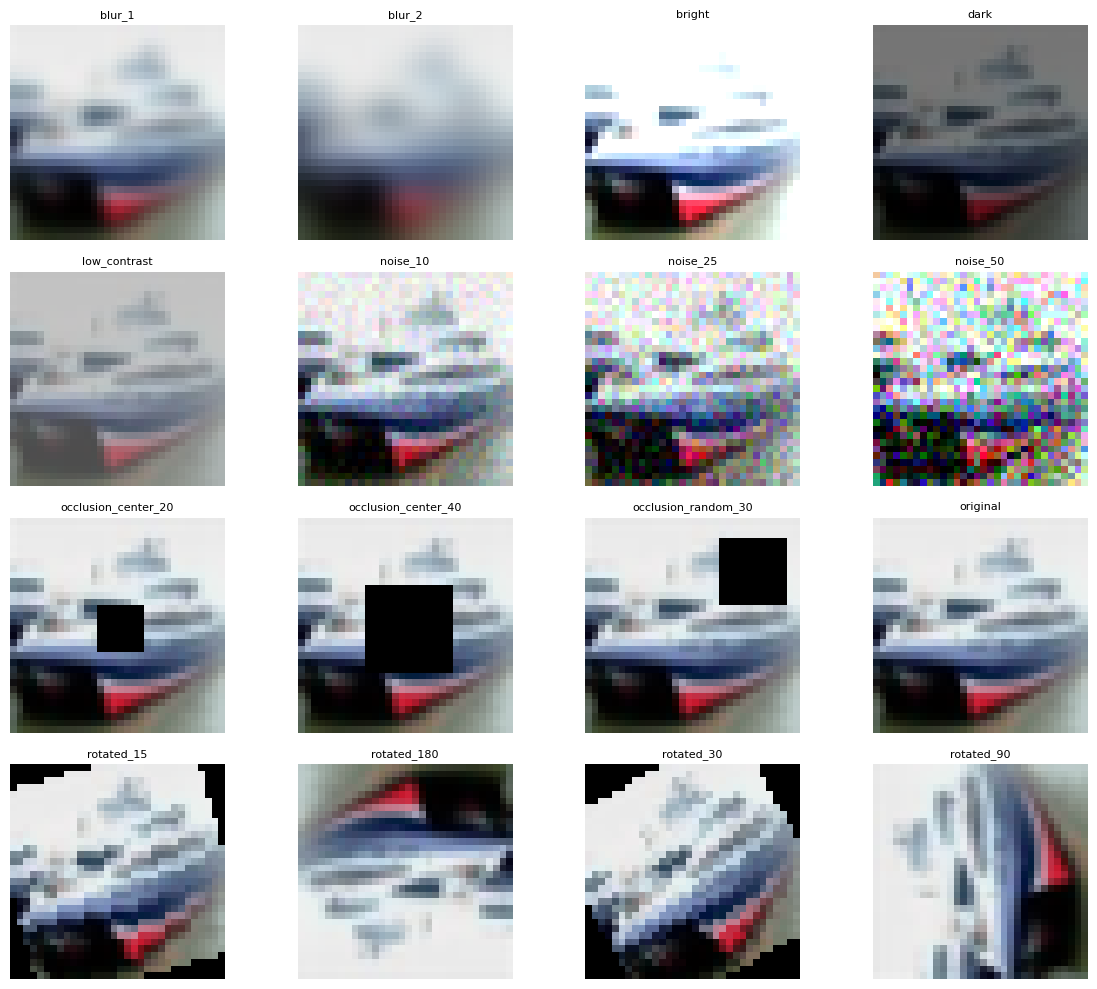

In [8]:
variants_loaded = images.load_image_variants()
images.show_structured_images(variants_loaded)

In [9]:
TRUE_MODIFIED_CLASS = "ship"

modified_rows = []

for image_variant, img in variants_loaded.items():
    for model_name, model_info in loaded_models.items():
        model = model_info["model"]

        img_tensor = adom.preprocess_pil_image(img)

        predictions = adom.predict_topk_classes(
            model=model,
            image_tensor=img_tensor,
            classes=classes,
            k=5
        )

        top1 = predictions[0]

        modified_rows.append({
            "image_variant": image_variant,
            "model": model_name,
            "true_class": TRUE_MODIFIED_CLASS,
            "top1_class": top1["class_name"],
            "top1_probability_percent": top1["probability_percent"],
            "is_correct": top1["class_name"] == TRUE_MODIFIED_CLASS,
            "topk_predictions": predictions,
        })

modified_df = pd.DataFrame(modified_rows)

if modified_df.empty:
    print("Brak wyników. Sprawdź, czy folder modified_images istnieje i zawiera obrazy.")
else:
    display(modified_df[[
        "image_variant", 
        "model", 
        "top1_class", 
        "top1_probability_percent", 
        "is_correct"
    ]].sort_values(["image_variant", "model"]))
    export_to_csv(modified_df, "modified_images_evaluation.csv")


    print("Podsumowanie wyników dla każdego wariantu obrazu:")
    
    pivot = modified_df.pivot(
        index="image_variant",
        columns="model",
        values="top1_class"
    )

    display(pivot)
    export_to_csv(pivot.reset_index(), "modified_images_top1_classes.csv")


,image_variant,model,top1_class,top1_probability_percent,is_correct
1,blur_1,AlexNet,ship,56.628865,True
2,blur_1,GoogLeNet,ship,51.460570,True
0,blur_1,VGG16,ship,45.472118,True
4,blur_2,AlexNet,ship,30.268934,True
5,blur_2,GoogLeNet,airplane,29.428124,False
3,blur_2,VGG16,ship,94.887477,True
7,bright,AlexNet,ship,51.450998,True
8,bright,GoogLeNet,ship,99.211192,True
6,bright,VGG16,ship,71.021307,True
10,dark,AlexNet,ship,59.445828,True


Podsumowanie wyników dla każdego wariantu obrazu:


model,AlexNet,GoogLeNet,VGG16
image_variant,,,
blur_1,ship,ship,ship
blur_2,ship,airplane,ship
bright,ship,ship,ship
dark,ship,ship,ship
low_contrast,ship,ship,ship
noise_10,ship,ship,automobile
noise_25,ship,ship,truck
noise_50,truck,frog,ship
occlusion_center_20,ship,ship,ship


### Podsumowanie odporności na transformacje

Zbiorcze wyniki dla wszystkich przeprowadzonych modyfikacji obrazu.

In [10]:
if not modified_df.empty:
    robustness_df = (
        modified_df
        .groupby("model")
        .agg(
            correct_variants=("is_correct", "sum"),
            total_variants=("is_correct", "count"),
            avg_confidence=("top1_probability_percent", "mean"),
        )
        .reset_index()
    )
    robustness_df["accuracy_on_variants_percent"] = 100 * robustness_df["correct_variants"] / robustness_df["total_variants"]
    robustness_df = robustness_df.sort_values("accuracy_on_variants_percent", ascending=False)

    display(robustness_df)
else:
    print("Pominięto podsumowanie, bo nie ma wyników dla modified_images.")

,model,correct_variants,total_variants,avg_confidence,accuracy_on_variants_percent
1,GoogLeNet,12,16,83.432183,75.0
0,AlexNet,10,16,49.947734,62.5
2,VGG16,10,16,73.509218,62.5


## Badanie rozpoznawania obrazów zewnętrznych (spoza CIFAR-10)

Ten eksperyment pokazuje generalizację poza CIFAR-10. Wyniki mogą być słabsze, bo modele były trenowane na małych obrazach CIFAR-10, a obrazy zewnętrzne mogą mieć inny styl, rozdzielczość, tło i kompozycję.

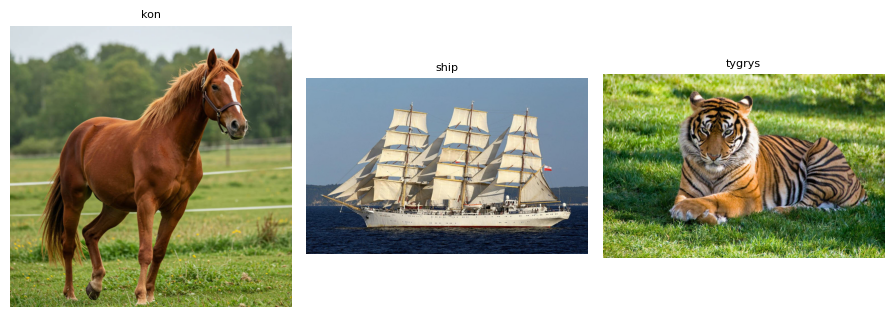

In [11]:
external_images = images.load_external_images()
images.show_structured_images(external_images)

In [12]:
external_rows = []

for image_name, img in external_images.items():
    for model_name, model_info in loaded_models.items():
        model = model_info["model"]

        img_tensor = adom.preprocess_pil_image(img)

        predictions = adom.predict_topk_classes(
            model=model,
            image_tensor=img_tensor,
            classes=classes,
            k=3
        )

        top1 = predictions[0]
        top2 = predictions[1]

        external_rows.append({
            "image": image_name,
            "model": model_name,

            "top1_class": top1["class_name"],
            "top1_conf": top1["probability_percent"],

            "top2_class": top2["class_name"],
            "top2_conf": top2["probability_percent"],
        })

external_df = pd.DataFrame(external_rows)

if external_df.empty:
    print("Brak wyników. Sprawdź folder external_images.")
else:
    display(
        external_df
        .sort_values(["image", "model"])
        .reset_index(drop=True)
        .style.format({
            "top1_conf": "{:.2f}%",
            "top2_conf": "{:.2f}%"
        })
    )

    export_to_csv(external_df, "external_images_evaluation.csv")

,image,model,top1_class,top1_conf,top2_class,top2_conf
0,kon,AlexNet,horse,95.43%,deer,1.80%
1,kon,GoogLeNet,horse,100.00%,dog,0.00%
2,kon,VGG16,horse,100.00%,deer,0.00%
3,ship,AlexNet,ship,49.35%,truck,18.91%
4,ship,GoogLeNet,ship,99.96%,bird,0.02%
5,ship,VGG16,truck,99.47%,ship,0.53%
6,tygrys,AlexNet,truck,48.70%,ship,12.41%
7,tygrys,GoogLeNet,bird,99.23%,frog,0.18%
8,tygrys,VGG16,frog,61.66%,dog,34.00%
